# Cleaning the data

## Disclaimer

My group did not want to take my input on this.

## Theoretical analysis and data exploration.

So we note we have to transform the data. 

**Why**?
Well because trying to deal with percentages, and count data does not make any sense for forcasting models without transformations. This is because we will get possibly negative estimates for our forecast (with expoential smoothing and ARIMA), which is so obviously an egregious model error... 

So my model will work slightly differently but we must note these formulas

percent_unweighted_ili = ilitotal/total_patients * 100.

This is just a fact, in the way the data is produced.

Now we define:

non_ilitotal = total_patients - ilitotal

This is really important as we will say that the model for non_ilitotal cases in the population is roughly independent of the number of ilitotal **given** the num_of_providers. Due to a sufficiently large population, and that we have low flu rates.

The we will need to adjust the this percent_unweighted_ili to calculate the percent_weighted_ili from the unweighted percent by state and then adjusting for population size to get for the whole of the US. This formula and determininstic, but we do not have access to that data so trying to guess it is rather silly.

Lastly we note that we will not neccessarily know the number of provides in the future time period, (even though the CDC has markov models to determine this very accurately). Thus we will try to predict this too.


### Conclusion
The best thing to model is the ilitotal. Which is the sum of all the subgroups by age (age_0_4,	age_25_49,	age_25_64,	age_5_24,	age_50_64,	age_65).
This still depends on the number of providers very heavily.

Then we will also try model the number of patients not with non flu like symptoms (non_ilitotal).

Using this we should be able to rather accurately calculate the percentage_unweighted prediction exactly (although this will take the estimation of a couple of intergrals) and we will likily use a MC estimation. 

We will then also try to estimate the precentage_weighted for the next time period and calculate the RMSE based off that.

For completeness we have included the basic iid,persistence, average, as well as exponential smoothing the original data.

In [39]:
df = read.csv("./data/fluview_clean/ilinet_clean.csv")
head(df)

,region_type,region,year,week,percent_weighted_ili,percent_unweighted_ili,age_0_4,age_25_49,age_25_64,age_5_24,age_50_64,age_65,ilitotal,num_of_providers,total_patients,week_start
,<chr>,<lgl>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
1,National,NA,1997,40,1.10148,1.21686,179,NA,157,205,NA,29,570,192,46842,1997-09-29
2,National,NA,1997,41,1.20007,1.28064,199,NA,151,242,NA,23,615,191,48023,1997-10-06
3,National,NA,1997,42,1.37876,1.23906,228,NA,153,266,NA,34,681,219,54961,1997-10-13
4,National,NA,1997,43,1.19920,1.14473,188,NA,193,236,NA,36,653,213,57044,1997-10-20
5,National,NA,1997,44,1.65618,1.26112,217,NA,162,280,NA,41,700,213,55506,1997-10-27
6,National,NA,1997,45,1.41326,1.28275,178,NA,148,281,NA,48,655,195,51062,1997-11-03


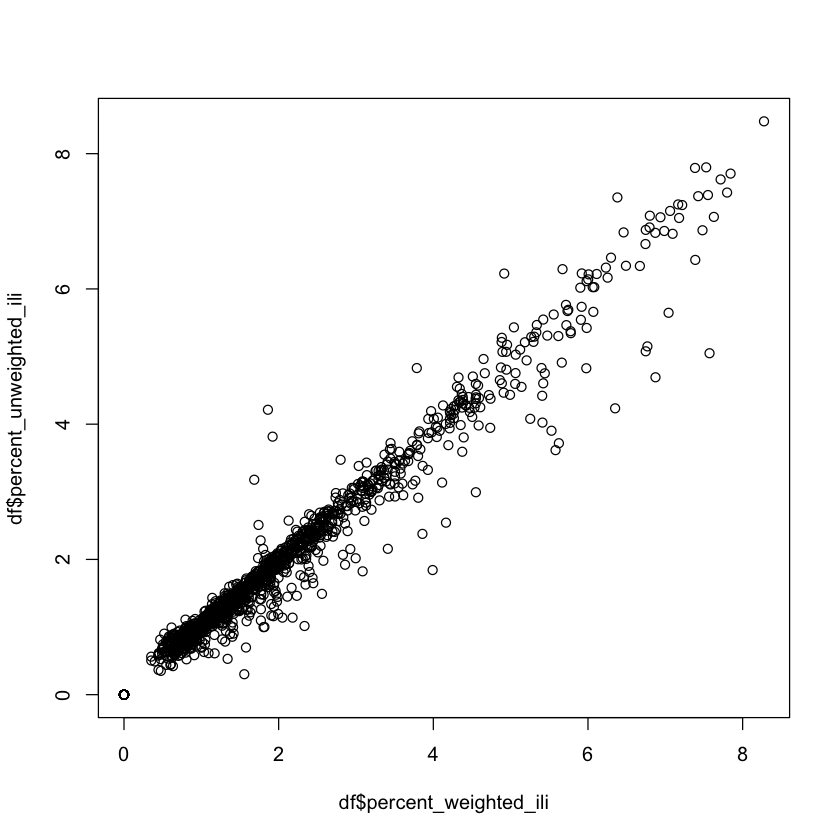

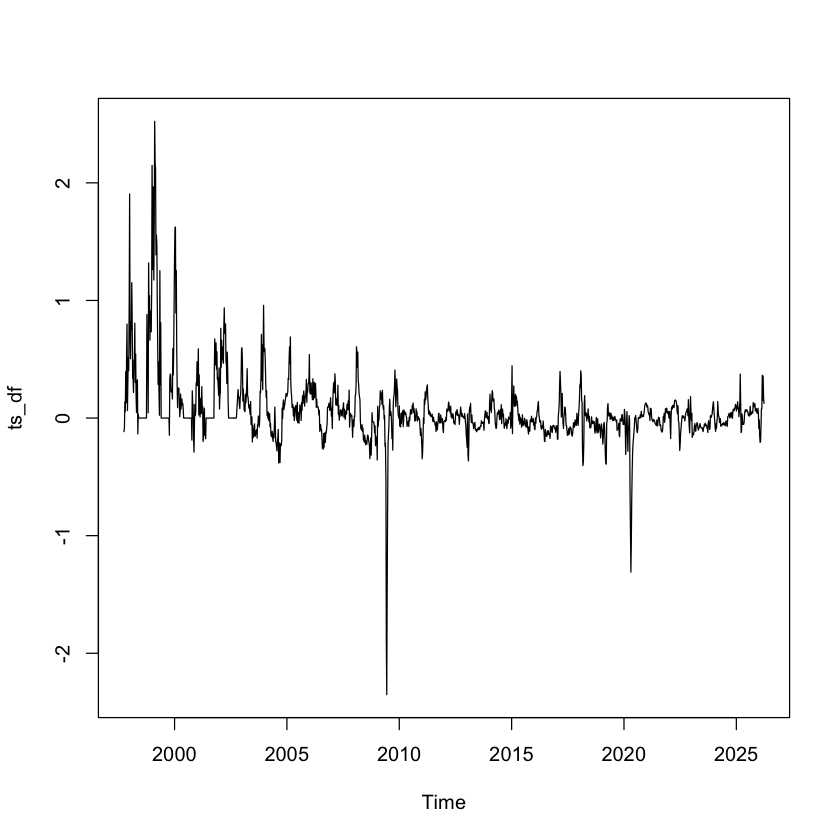

In [40]:

plot(df$percent_weighted_ili, df$percent_unweighted_ili)
ts_percent_weighted_ili = ts(df$percent_weighted_ili,start = c(1997,40), frequency = 52)
ts_percent_unweighted_ili = ts(df$percent_unweighted_ili,start = c(1997,40), frequency = 52)
ts_df = ts(df$percent_weighted_ili- df$percent_unweighted_ili, start = c(1997,40), frequency = 52)
plot(ts_df)

# model  = glm(df$percent_weighted_ili ~ df$percent_unweighted_ili, family = "poisson")
# hist(model$residuals)




So we see that the model is

So now we want to foculs on this and model the number of non

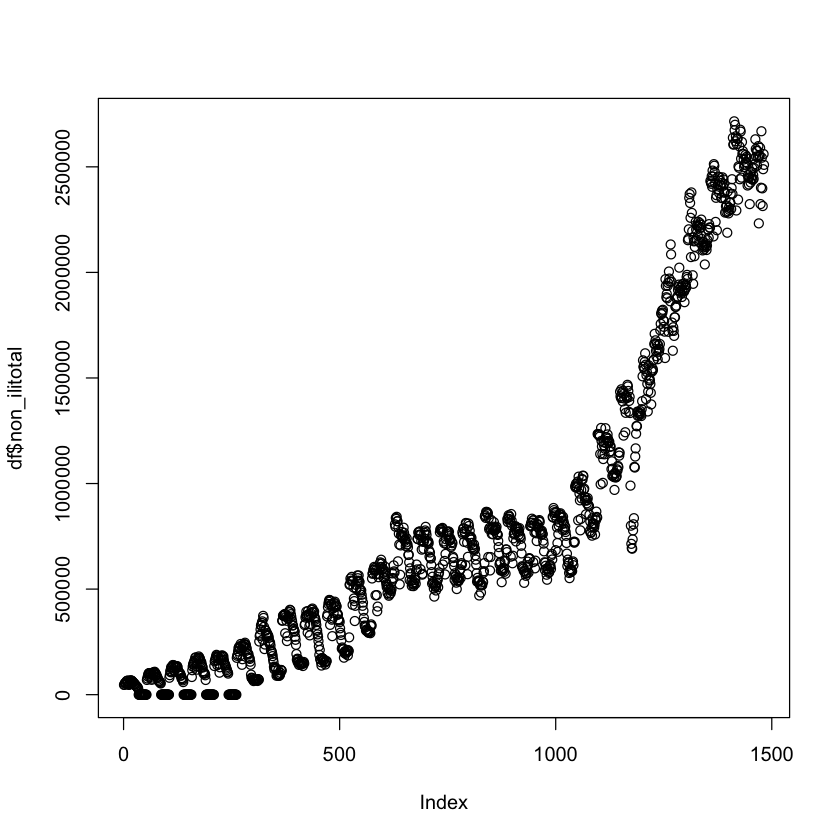

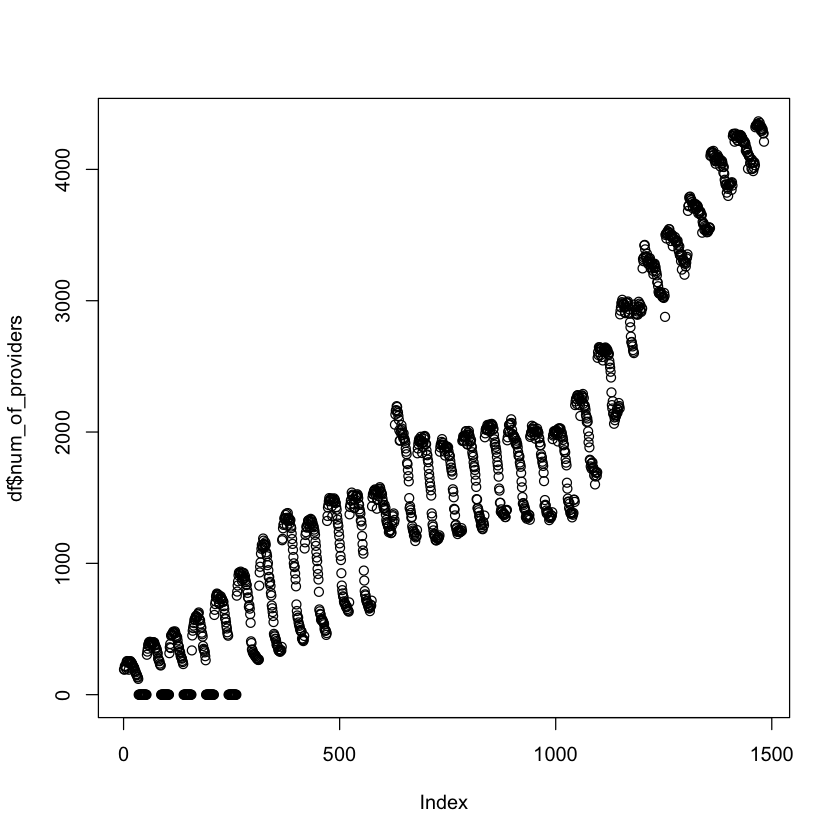

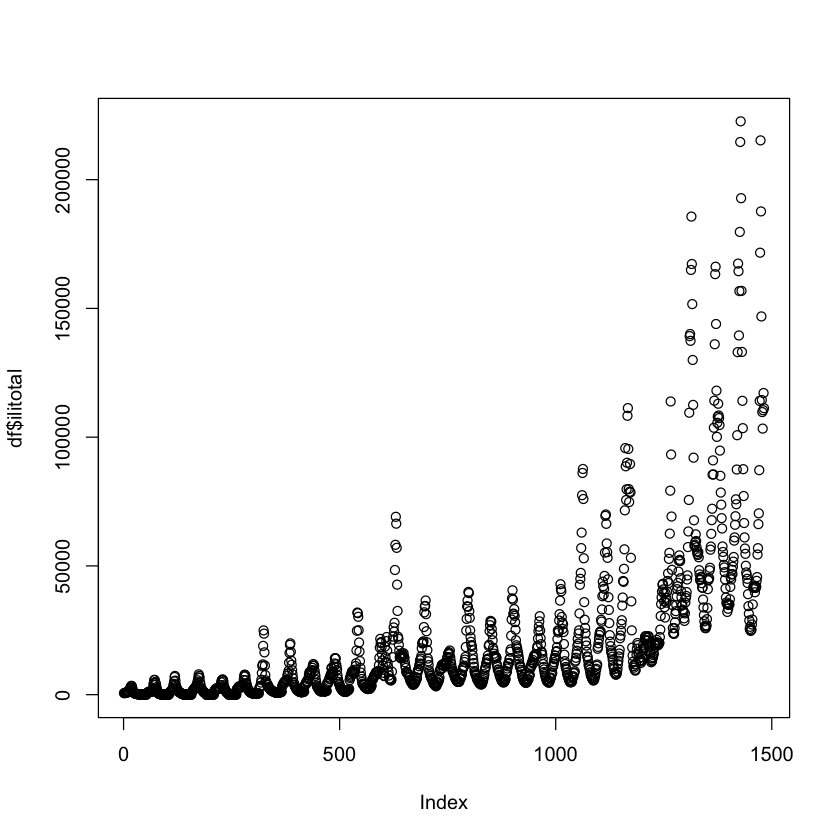

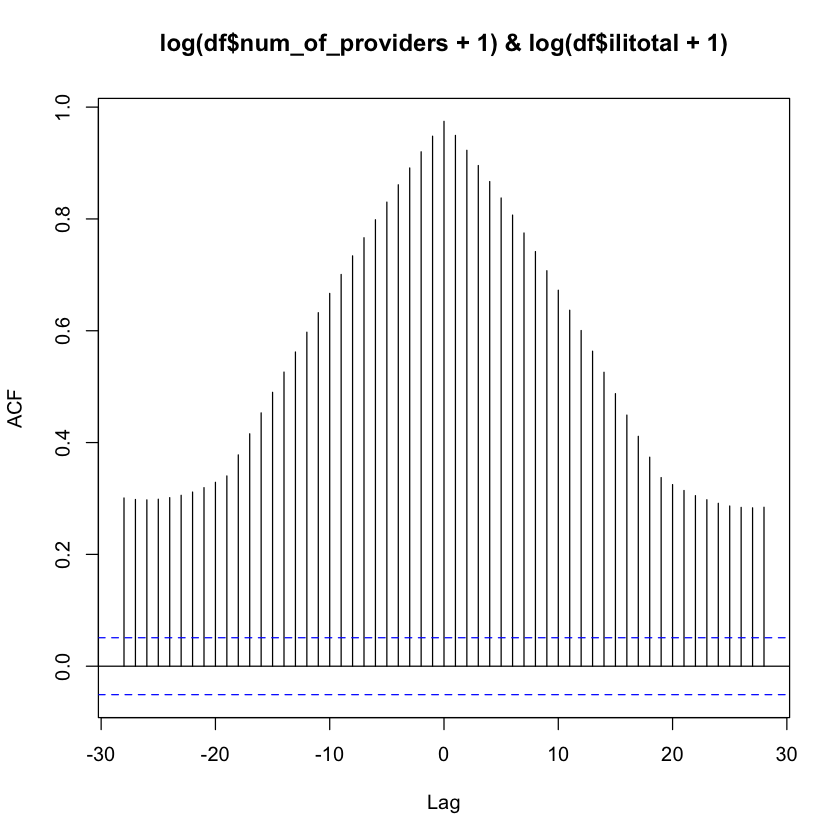

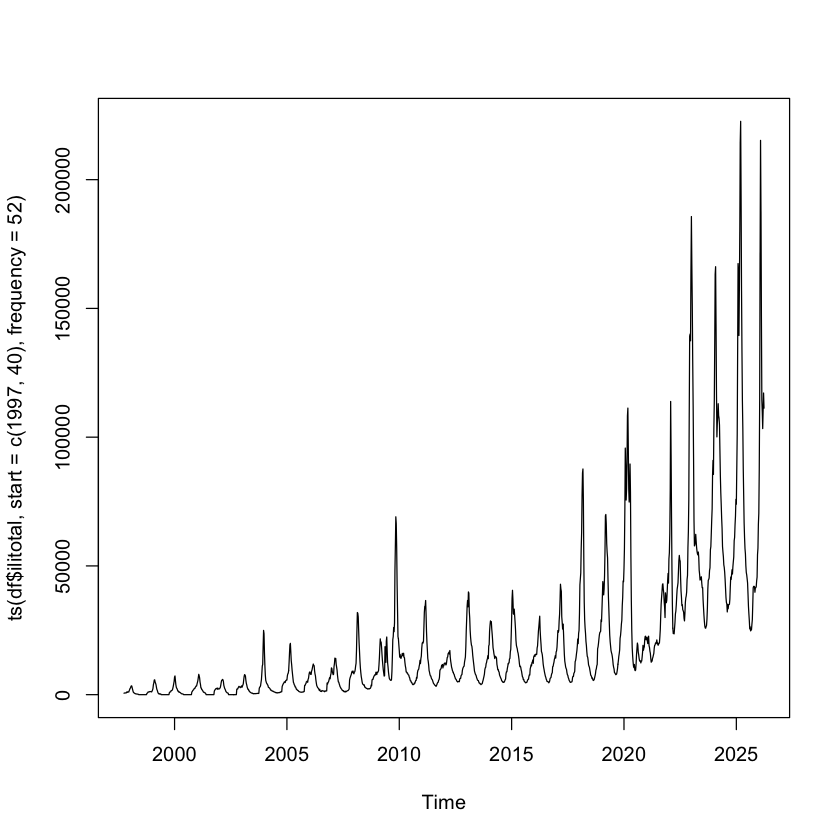

In [41]:
df$non_ilitotal= df$total_patients-df$ilitotal

plot(df$non_ilitotal)
plot(df$num_of_providers)
plot(df$ilitotal)
ccf(log(df$num_of_providers+1), log(df$ilitotal+1))
plot(ts(df$ilitotal, start = c(1997,40), frequency = 52))

This may look slightly daunting but remember that this is simply just a clear seasonal pattern and we can see that the only other likily predictor for this is the num_of_providers since if we consider that we have less people providing data we would get much fewer total number of accidents. Now lookign at these plots these are clearly quite related!

So we take the log difference of these of these values and we get a lovely plot. That exhibts a constant factor with slight seasonality.


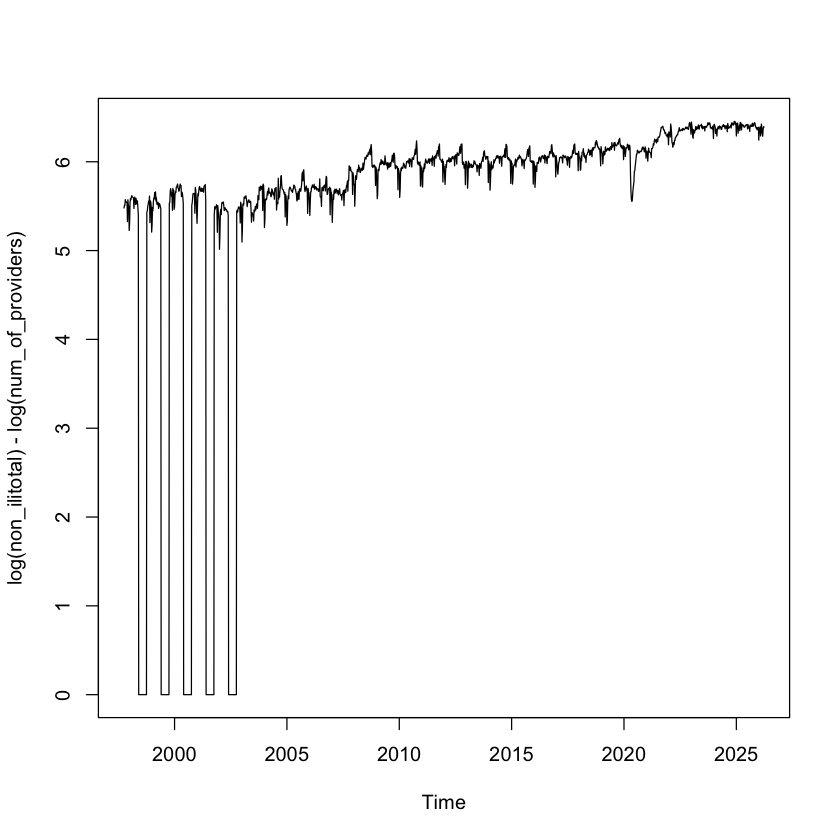

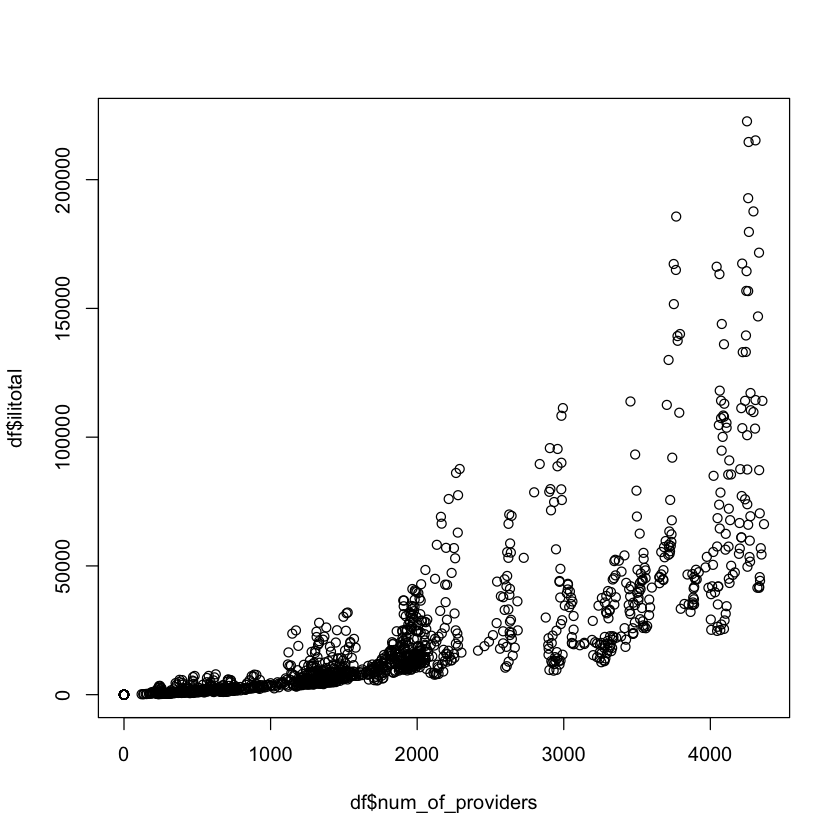

In [42]:
plot(ts(log(df$non_ilitotal+1)-log(df$num_of_providers+1),start = c(1997,40), frequency = 52),ylab = "log(non_ilitotal) - log(num_of_providers)" )

# Note that we still have these periods where the number of providers is 0 thus of course the difference is zero.

plot(df$num_of_providers,df$ilitotal)


In [43]:
# ccf(x=log(df$ilitotal+1)-log(df$num_of_providers+1), y=log(df$non_ilitotal+1)-log(df$num_of_providers+1), lag.max = 20)
# acf(df$num_of_providers)



In [44]:
# fdf = dataread.csv("./data/fluview_clean/ilinet_final.csv")

# df$ilitotal = df$ilitotal
# fdf$percent_weighted_ili = df$percent_weighted_ili
# fdf$percent_unweighted_ili = df$percent_unweighted_ili
# fdf$non_ilitotal = df$non_ilitotal
# fdf$num_of_providers = df$num_of_providers
# # Those are our base variables done.
# # Now we need these
# # age_0_4","age_25_49","age_25_64","age_5_24","age_50_64","age_65"
# fdf$age_0_4 = logp1(df$age_0_4)
# fdf$age_5_24 = logp1(df$age_5_24)
# fdf$age_25_64 = logp1(df$age_25_64)
# fdf$age_25_49 = logp1(df$age_25_49)
# fdf$age_50_64 = logp1(df$age_50_64)
# fdf$age_65_plus = logp1(df$age_65_plus)
# fdf$week = df$week
# fdf$year = df$year
logp1 = function(x){
    return(log(x+1))
}
percentage_transform <- function(x){
    return(log((x/100)/(1-x/100)))
}
# transformed_ili = percentage_t/ransform(df$percent_weighted_ili)
# plot(transformed_ili)

In [45]:
# logit = function(x){
#     return(log(x/(1-x)))
# }
# inv_logit = function(x){
#     return(exp(x)/(1+exp(x)))
# }
# df$logit_percent_weighted_ili
# plot(df$logit_percent_weighted_ili)

In [46]:
# Now lets just do the transforms
df = read.csv("./data/fluview_clean/ilinet_clean.csv")
head(df)
fdf = data.frame(list(ilitotal = df$ilitotal))
fdf$ilitotal = df$ilitotal
fdf$percent_weighted_ili = df$percent_weighted_ili
fdf$percent_unweighted_ili = df$percent_unweighted_ili
fdf$pw_trans = percentage_transform(df$percent_weighted_ili+0.1)
fdf$puw_trans = percentage_transform(df$percent_unweighted_ili+0.1)
fdf$year = df$year
fdf$week = df$week
fdf$age_0_4 = logp1(df$age_0_4)
fdf$age_5_24 = logp1(df$age_5_24)
fdf$age_25_64 = logp1(df$age_25_64)
fdf$age_25_49 = logp1(df$age_25_49)
fdf$age_50_64 = logp1(df$age_50_64)
fdf$age_65 = logp1(df$age_65)
fdf$num_of_providers =logp1(df$num_of_providers)
fdf$non_ilitotal = logp1(df$total_patients-df$ilitotal)

head(fdf)
write.csv(fdf, "./data/fluview_clean/ilinet_final.csv", row.names = T)

,region_type,region,year,week,percent_weighted_ili,percent_unweighted_ili,age_0_4,age_25_49,age_25_64,age_5_24,age_50_64,age_65,ilitotal,num_of_providers,total_patients,week_start
,<chr>,<lgl>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
1,National,NA,1997,40,1.10148,1.21686,179,NA,157,205,NA,29,570,192,46842,1997-09-29
2,National,NA,1997,41,1.20007,1.28064,199,NA,151,242,NA,23,615,191,48023,1997-10-06
3,National,NA,1997,42,1.37876,1.23906,228,NA,153,266,NA,34,681,219,54961,1997-10-13
4,National,NA,1997,43,1.19920,1.14473,188,NA,193,236,NA,36,653,213,57044,1997-10-20
5,National,NA,1997,44,1.65618,1.26112,217,NA,162,280,NA,41,700,213,55506,1997-10-27
6,National,NA,1997,45,1.41326,1.28275,178,NA,148,281,NA,48,655,195,51062,1997-11-03


,ilitotal,percent_weighted_ili,percent_unweighted_ili,pw_trans,puw_trans,year,week,age_0_4,age_5_24,age_25_64,age_25_49,age_50_64,age_65,num_of_providers,non_ilitotal
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,570,1.10148,1.21686,-4.409528,-4.316664,1997,40,5.192957,5.327876,5.062595,NA,NA,3.401197,5.262690,10.74231
2,615,1.20007,1.28064,-4.329666,-4.268720,1997,41,5.298317,5.493061,5.023881,NA,NA,3.178054,5.257495,10.76657
3,681,1.37876,1.23906,-4.199068,-4.299721,1997,42,5.433722,5.587249,5.036953,NA,NA,3.555348,5.393628,10.90193
4,653,1.19920,1.14473,-4.330344,-4.373726,1997,43,5.241747,5.468060,5.267858,NA,NA,3.610918,5.365976,10.94008
5,700,1.65618,1.26112,-4.024311,-4.283158,1997,44,5.384495,5.638355,5.093750,NA,NA,3.737670,5.365976,10.91157
6,655,1.41326,1.28275,-4.175656,-4.267172,1997,45,5.187386,5.641907,5.003946,NA,NA,3.891820,5.278115,10.82791


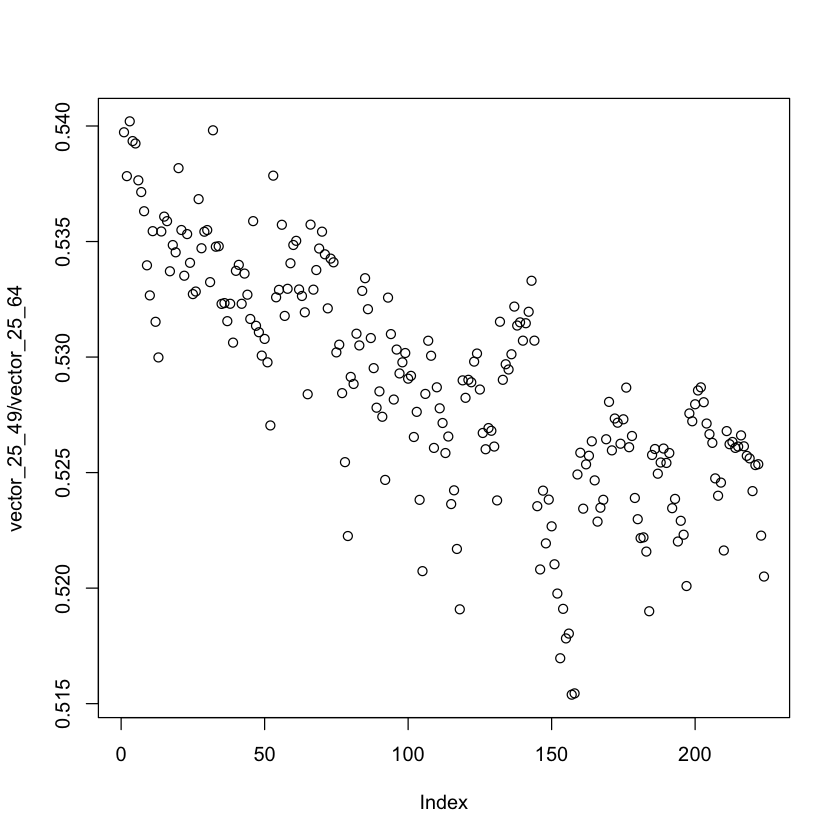

In [47]:
# We need to explore one more relationship that is the relationship after 2009 week 40 between the number of age_25_49 to age_25_64
# This is because 
vector_25_49 = fdf$age_25_49[which(fdf$year >= 2009 & fdf$week >= 40)]
vector_50_64 = fdf$age_50_64[which(fdf$year >= 2009 & fdf$week >= 40)]
vector_25_64 = fdf$age_25_64[which(fdf$year >= 2009 & fdf$week >= 40)]
vector_25_64= vector_25_49 + vector_50_64

plot(vector_25_49/vector_25_64)
# what this graph says is that we do not have a constant proportion of flue cases in the population.

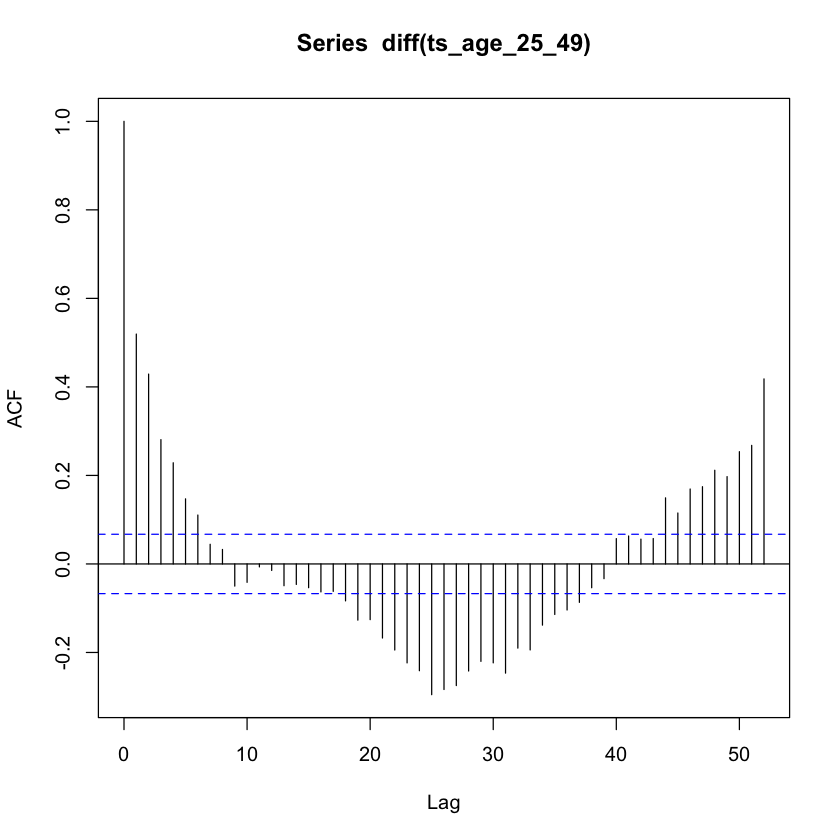

In [48]:
# acf(diff(fdf$age_5_24),lag.max = 52)
# ts_age_25_49 <- ts(fdf$age_25_49,start = c(1997,40), frequency = 52)
ts_age_25_49<-fdf$age_25_49[!is.na(fdf$age_25_49)& fdf$age_25_49!=0]
acf(diff(ts_age_25_49),lag.max = 52)
# pacf(diff(fdf$age_5_24),lag.max = 52)

Next objective is to try and compute the 

In [61]:
#
head(df)

,region_type,region,year,week,percent_weighted_ili,percent_unweighted_ili,age_0_4,age_25_49,age_25_64,age_5_24,age_50_64,age_65,ilitotal,num_of_providers,total_patients,week_start,non_ilitotal
,<chr>,<lgl>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<int>
1,National,NA,1997,40,1.10148,1.21686,179,NA,157,205,NA,29,570,192,46842,1997-09-29,46272
2,National,NA,1997,41,1.20007,1.28064,199,NA,151,242,NA,23,615,191,48023,1997-10-06,47408
3,National,NA,1997,42,1.37876,1.23906,228,NA,153,266,NA,34,681,219,54961,1997-10-13,54280
4,National,NA,1997,43,1.19920,1.14473,188,NA,193,236,NA,36,653,213,57044,1997-10-20,56391
5,National,NA,1997,44,1.65618,1.26112,217,NA,162,280,NA,41,700,213,55506,1997-10-27,54806
6,National,NA,1997,45,1.41326,1.28275,178,NA,148,281,NA,48,655,195,51062,1997-11-03,50407
